# 08_time_reversal_baseline.ipynb

Экспериментальный **time-reversal / adjoint imaging baseline** для текущей постановки.

## Важная оговорка
В классическом виде time reversal обычно используют с **time-domain waveforms** и time-varying sensor data; у k-Wave это именно time-reversal image reconstruction examples для circular/line sensors и time-varying pressure data.

У нас сейчас данные другие:
- single-frequency,
- комплексные,
- уже сведённые к матрице `M[s, r]`.

Поэтому здесь реализуется **single-frequency frequency-domain backprop / adjoint imaging**, а не “полный broadband time reversal”.

## Что делает ноутбук
- читает test `.npz`;
- строит `M_hom`;
- берёт residual:
  \[
  M_{res} = M - M_{hom}
  \]
- для каждого источника backpropagates conjugated receiver data в однородной среде;
- суммирует энергию backpropagated fields и получает **imaging functional**.

## Что считать target
Такой метод лучше сравнивать не с точной speed map, а с **картой аномалии**:
\[
A(x,y) = |c(x,y) - c_{bg}|
\]

То есть это baseline для **локализации аномалий**, а не для точной количественной speed reconstruction.

## 0. Важно про JAX
Эта ячейка должна выполняться **до любого `import jax`**.

Если в текущем kernel JAX уже импортировался, лучше перезапустить kernel и начать с начала.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".50"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [3]:
OUT_ROOT = Path("/workspace/usct_dataset_v2")
TEST_DIR = OUT_ROOT / "test"
assert TEST_DIR.exists(), TEST_DIR

test_files = sorted(TEST_DIR.glob("*.npz"))
print("test:", len(test_files))
assert len(test_files) > 0

test: 800


In [4]:
CFG = {
    "background_speed": 1500.0,
    "density": 1000.0,
    "pml_size": 16,
    "source_sigma_px": 1.8,
    "mask_half_width": 4,
    "num_examples_to_run": 3,
    "example_indices_from_test": [0, 1, 2],
    "save_run_name": "time_reversal_baseline_v1",
}
CFG

{'background_speed': 1500.0,
 'density': 1000.0,
 'pml_size': 16,
 'source_sigma_px': 1.8,
 'mask_half_width': 4,
 'num_examples_to_run': 3,
 'example_indices_from_test': [0, 1, 2],
 'save_run_name': 'time_reversal_baseline_v1'}

file: /workspace/usct_dataset_v2/test/sample_00000.npz
keys: ['x', 'c', 'receiver_y', 'receiver_x', 'source_ring_idx', 'dx', 'freq_hz']
x                shape=(2, 16, 256) dtype=float32
c                shape=(192, 192) dtype=float32
receiver_y       shape=(256,) dtype=int64
receiver_x       shape=(256,) dtype=int64
source_ring_idx  shape=(16,) dtype=int64
dx               shape=(2,) dtype=float32
freq_hz          shape=(1,) dtype=float32


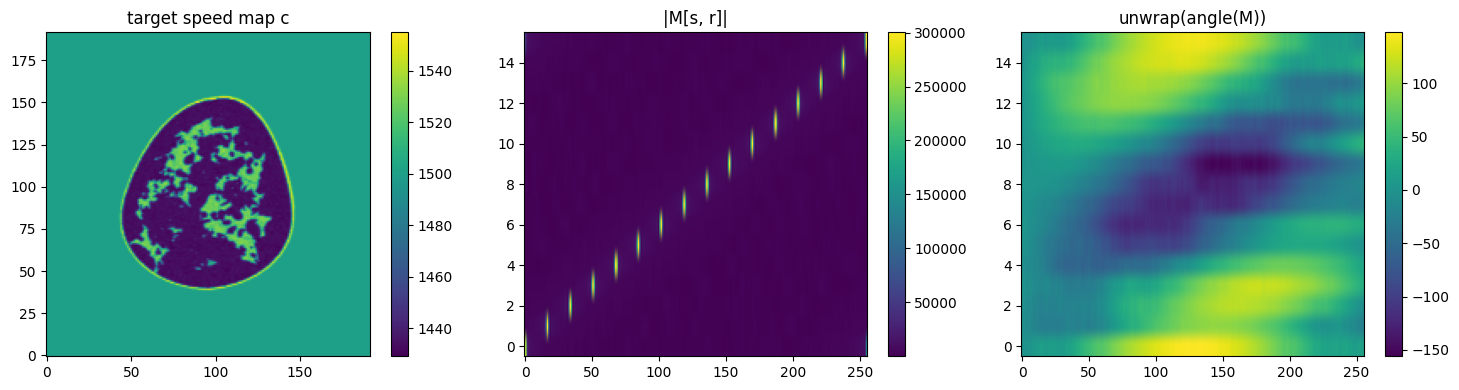

In [5]:
def inspect_npz(path: Path):
    d = np.load(path)
    print("file:", path)
    print("keys:", d.files)
    for k in d.files:
        arr = d[k]
        print(f"{k:16s} shape={arr.shape} dtype={arr.dtype}")

    x = d["x"]
    c = d["c"]
    M = x[0] + 1j * x[1]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(c, origin="lower")
    ax[0].set_title("target speed map c")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(np.abs(M), aspect="auto", origin="lower")
    ax[1].set_title("|M[s, r]|")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(np.unwrap(np.angle(M), axis=1), aspect="auto", origin="lower")
    ax[2].set_title("unwrap(angle(M))")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

inspect_npz(test_files[0])

In [6]:
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def mask_matrix(num_sources, num_receivers, source_ring_idx, half_width=4):
    mask = np.ones((num_sources, num_receivers), dtype=np.float32)
    for s in range(num_sources):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % num_receivers
            mask[s, rr] = 0.0
    return mask

def gaussian_source(H: int, W: int, y0: int, x0: int, sigma: float = 1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

In [7]:
sample0 = np.load(test_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx = np.array(sample0["source_ring_idx"].astype(np.int32))

domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

print("H, W:", H, W)
print("S, R:", S, R)
print("dx:", dx)
print("freq_hz:", freq_hz)

H, W: 192 192
S, R: 16 256
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0


/tmp/ipykernel_33817/2127527586.py:12: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
@jit
def solve_helmholtz_jit(medium, omega, src):
    return helmholtz_solver(medium, omega, src)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=CFG["density"],
        pml_size=CFG["pml_size"],
    )
    return medium

def forward_measurements(c_map, source_fields):
    medium = make_medium(c_map)

    ms = []
    for i in range(len(source_fields)):
        src = FourierSeries(jnp.expand_dims(source_fields[i], -1), domain)
        field = solve_helmholtz_jit(medium, omega, src * omega)
        u = np.array(field.params[..., 0])
        ms.append(u[receiver_y, receiver_x])

    return np.stack(ms, axis=0)

M_hom shape: (16, 256) complex64
time for homogeneous forward batch: 2.5369584560394287 sec


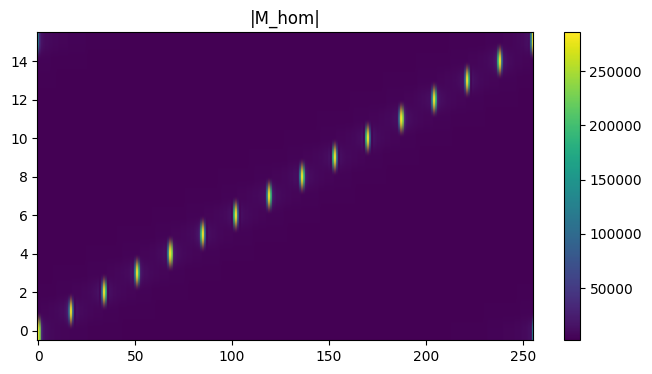

In [9]:
forward_source_fields = []
for ridx in source_ring_idx:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=CFG["source_sigma_px"])
    forward_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
forward_source_fields = tuple(forward_source_fields)

c_hom = np.full((H, W), CFG["background_speed"], dtype=np.float32)

t0 = time.time()
M_hom = forward_measurements(c_hom, forward_source_fields)
t1 = time.time()

print("M_hom shape:", M_hom.shape, M_hom.dtype)
print("time for homogeneous forward batch:", t1 - t0, "sec")

plt.figure(figsize=(8, 4))
plt.imshow(np.abs(M_hom), aspect="auto", origin="lower")
plt.title("|M_hom|")
plt.colorbar()
plt.show()

In [10]:
def build_backprop_source_field(receiver_weights_complex):
    src = np.zeros((H, W), dtype=np.complex64)
    for r in range(R):
        y = receiver_y[r]
        x = receiver_x[r]
        src[y, x] += receiver_weights_complex[r]
    return jnp.array(src, dtype=jnp.complex64)

def backprop_image_from_M(M_target_complex):
    M_res = M_target_complex - M_hom

    mask = mask_matrix(S, R, source_ring_idx, half_width=CFG["mask_half_width"])
    M_res = M_res * mask

    medium = make_medium(c_hom)
    image = np.zeros((H, W), dtype=np.float32)

    for s in range(S):
        w = np.conj(M_res[s])

        amp_norm = np.linalg.norm(w) + 1e-8
        w = w / amp_norm

        src_field = build_backprop_source_field(w)
        src = FourierSeries(jnp.expand_dims(src_field, -1), domain)

        field = solve_helmholtz_jit(medium, omega, src * omega)
        u_back = np.array(field.params[..., 0])

        image += np.abs(u_back) ** 2

    image = image / (image.max() + 1e-8)
    return image.astype(np.float32), M_res

In [11]:
def anomaly_target_from_c(c_true):
    anom = np.abs(c_true - CFG["background_speed"]).astype(np.float32)
    anom = anom / (anom.max() + 1e-8)
    return anom

def speed_like_map_from_image(image):
    c_vis = CFG["background_speed"] - 90.0 * image
    return c_vis.astype(np.float32)

def reconstruct_one_example_tr(npz_path: Path):
    d = np.load(npz_path)
    x = d["x"].astype(np.float32)
    c_true = d["c"].astype(np.float32)
    M_target = x[0] + 1j * x[1]

    t0 = time.time()
    image, M_res = backprop_image_from_M(M_target)
    t1 = time.time()

    anom_target = anomaly_target_from_c(c_true)
    speed_like = speed_like_map_from_image(image)
    metrics = compute_metrics(image, anom_target, data_range=1.0)

    return {
        "path": str(npz_path),
        "c_true": c_true,
        "anom_target": anom_target,
        "tr_image": image,
        "speed_like": speed_like,
        "M_res": M_res,
        "metrics": metrics,
        "runtime_sec": t1 - t0,
    }

In [12]:
example_ids = CFG["example_indices_from_test"][:CFG["num_examples_to_run"]]
example_paths = [test_files[i] for i in example_ids]

print("example_paths:")
for p in example_paths:
    print(p)

example_paths:
/workspace/usct_dataset_v2/test/sample_00000.npz
/workspace/usct_dataset_v2/test/sample_00001.npz
/workspace/usct_dataset_v2/test/sample_00002.npz


In [13]:
result0 = reconstruct_one_example_tr(example_paths[0])

print("runtime_sec:", result0["runtime_sec"])
print("metrics:", json.dumps(result0["metrics"], ensure_ascii=False, indent=2))

runtime_sec: 1.4919967651367188
metrics: {
  "mse": 0.11272907257080078,
  "rmse": 0.3357515037059784,
  "relative_l2": 0.8483611941337585,
  "psnr": 9.479640659519603
}


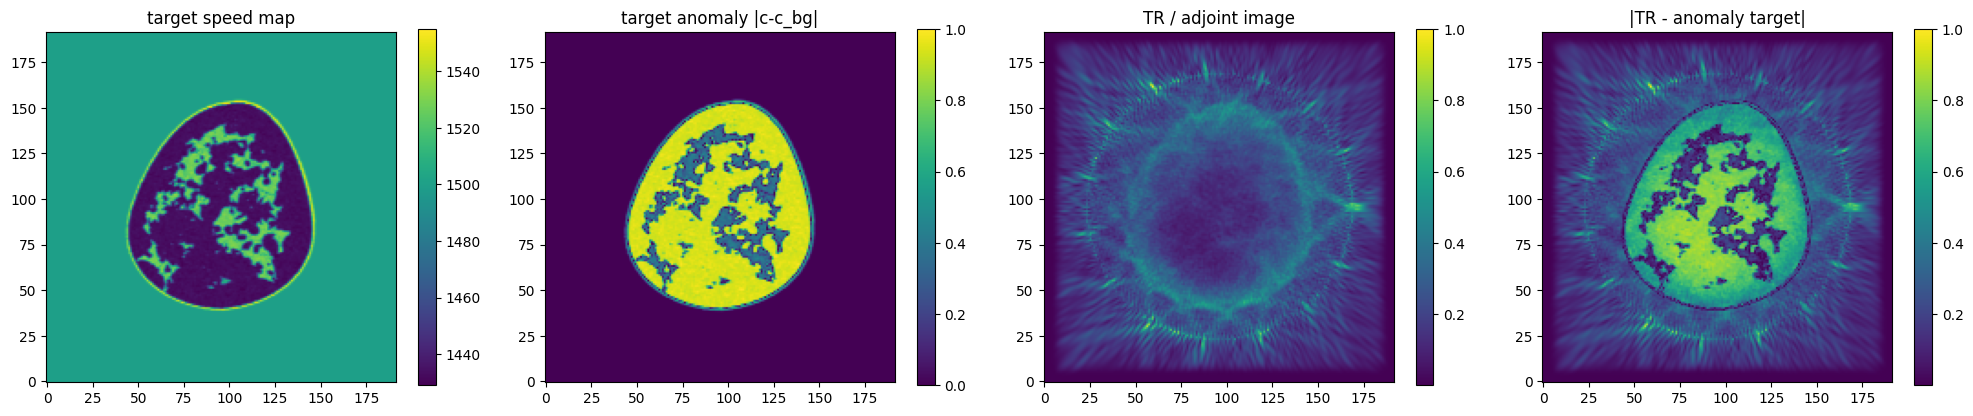

In [14]:
def show_tr_result(result):
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))

    im0 = ax[0].imshow(result["c_true"], origin="lower")
    ax[0].set_title("target speed map")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(result["anom_target"], origin="lower")
    ax[1].set_title("target anomaly |c-c_bg|")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(result["tr_image"], origin="lower")
    ax[2].set_title("TR / adjoint image")
    plt.colorbar(im2, ax=ax[2])

    im3 = ax[3].imshow(np.abs(result["tr_image"] - result["anom_target"]), origin="lower")
    ax[3].set_title("|TR - anomaly target|")
    plt.colorbar(im3, ax=ax[3])

    plt.tight_layout()
    plt.show()

show_tr_result(result0)

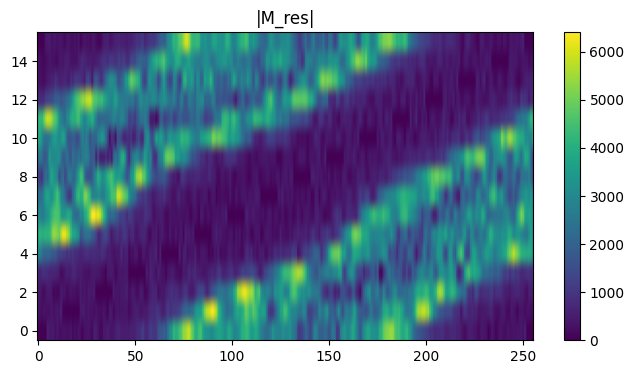

In [15]:
plt.figure(figsize=(8, 4))
plt.imshow(np.abs(result0["M_res"]), aspect="auto", origin="lower")
plt.title("|M_res|")
plt.colorbar()
plt.show()

In [16]:
results = []
for p in example_paths:
    print("=" * 80)
    print("processing:", p)
    res = reconstruct_one_example_tr(p)
    results.append(res)
    print("runtime_sec:", res["runtime_sec"])
    print(json.dumps(res["metrics"], ensure_ascii=False, indent=2))

processing: /workspace/usct_dataset_v2/test/sample_00000.npz
runtime_sec: 1.4928910732269287
{
  "mse": 0.11272907257080078,
  "rmse": 0.3357515037059784,
  "relative_l2": 0.8483611941337585,
  "psnr": 9.479640659519603
}
processing: /workspace/usct_dataset_v2/test/sample_00001.npz
runtime_sec: 1.4644498825073242
{
  "mse": 0.1428932249546051,
  "rmse": 0.37801221013069153,
  "relative_l2": 0.8618218898773193,
  "psnr": 8.449883620738458
}
processing: /workspace/usct_dataset_v2/test/sample_00002.npz
runtime_sec: 1.4301774501800537
{
  "mse": 0.1944088488817215,
  "rmse": 0.4409181773662567,
  "relative_l2": 0.9022984504699707,
  "psnr": 7.112839712356691
}


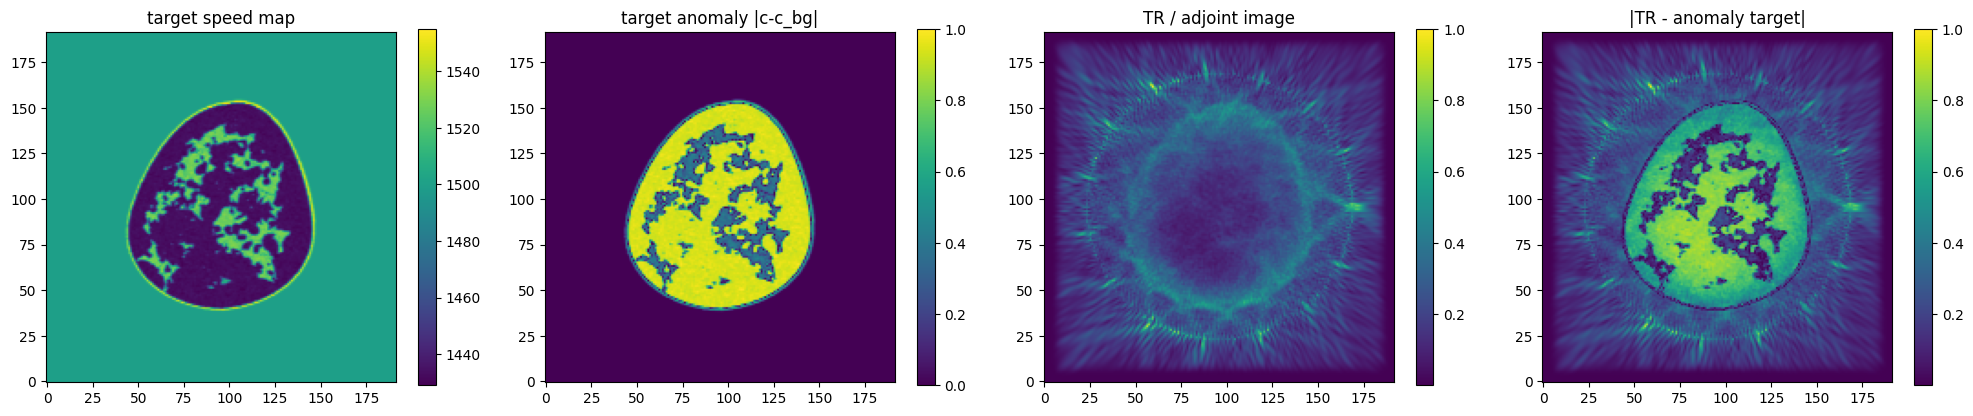

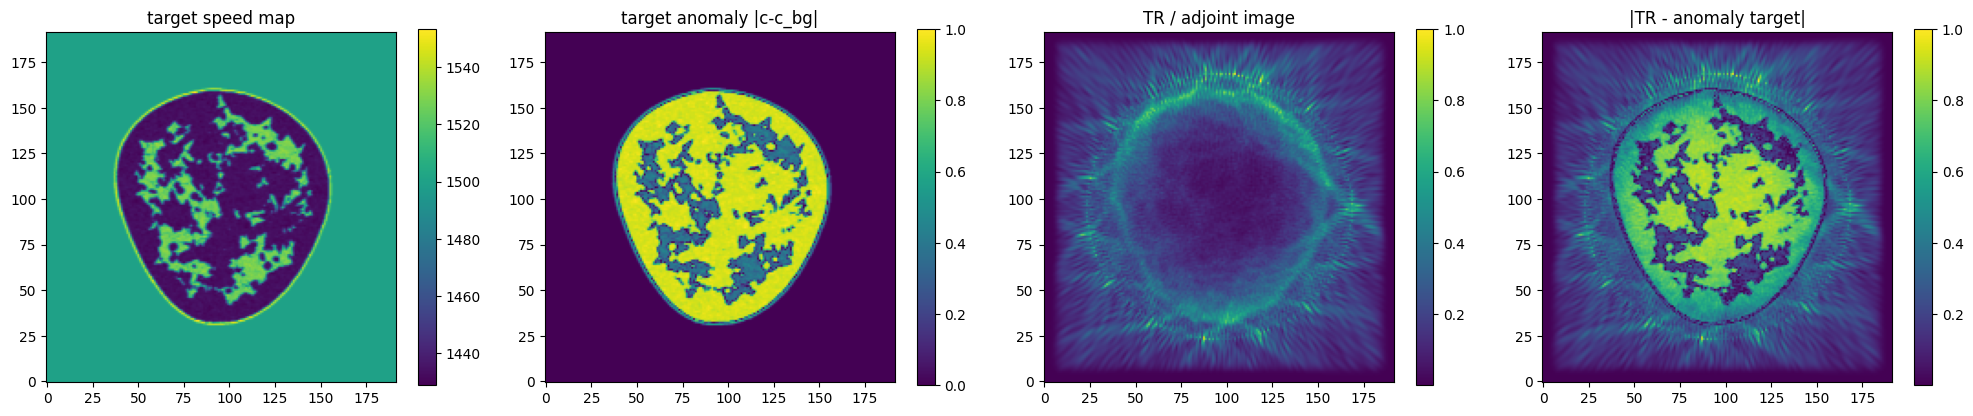

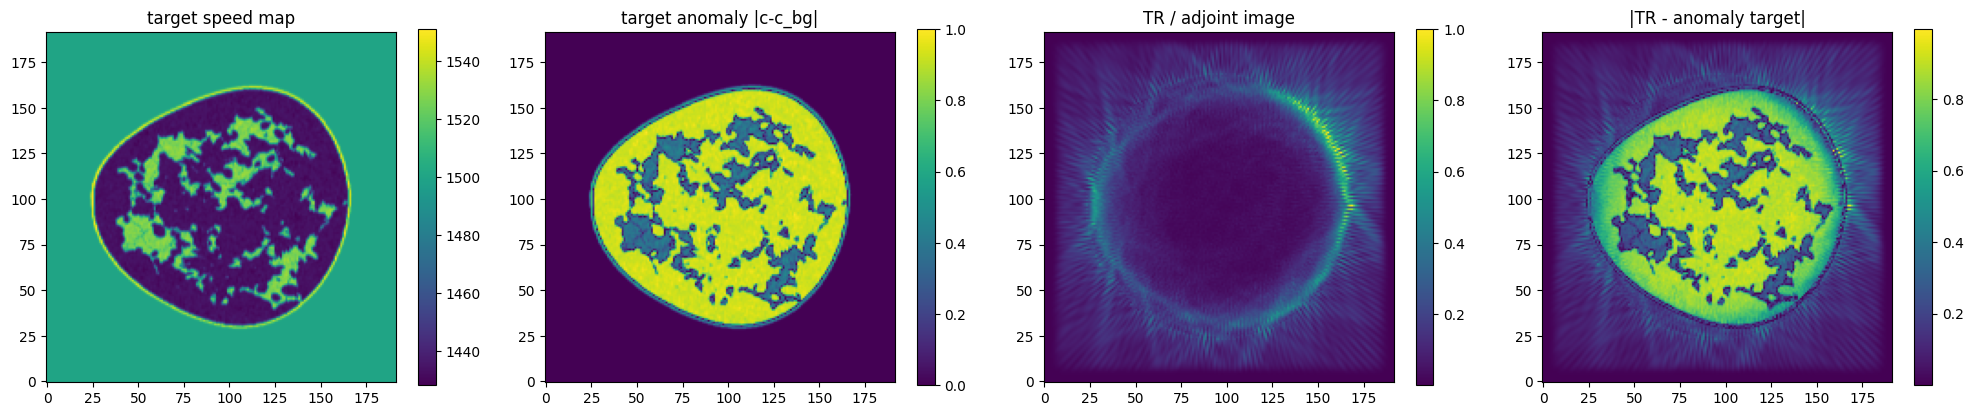

In [17]:
for res in results:
    show_tr_result(res)

In [18]:
metrics_list = []
for i, res in enumerate(results):
    row = dict(res["metrics"])
    row["index"] = i
    row["path"] = res["path"]
    row["runtime_sec"] = float(res["runtime_sec"])
    metrics_list.append(row)

summary = {}
for key in metrics_list[0].keys():
    if key in ("index", "path"):
        continue
    vals = [m[key] for m in metrics_list]
    summary[f"{key}_mean"] = float(np.mean(vals))
    summary[f"{key}_std"] = float(np.std(vals))

print("TIME-REVERSAL / ADJOINT BASELINE SUMMARY")
print(json.dumps(summary, ensure_ascii=False, indent=2))

TIME-REVERSAL / ADJOINT BASELINE SUMMARY
{
  "mse_mean": 0.15001038213570914,
  "mse_std": 0.03372325517409726,
  "rmse_mean": 0.3848939637343089,
  "rmse_std": 0.04320899760996965,
  "relative_l2_mean": 0.8708271781603495,
  "relative_l2_std": 0.022922017335085282,
  "psnr_mean": 8.347454664204918,
  "psnr_std": 0.9689531977776246,
  "runtime_sec_mean": 1.4625061353047688,
  "runtime_sec_std": 0.02563959495008926
}


In [19]:
RUN_NAME = CFG["save_run_name"]
OUT_DIR = Path("/workspace/reference_points") / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

config_to_save = {
    "run_name": RUN_NAME,
    "description": "Single-frequency adjoint / backprop imaging baseline, compared against anomaly map not exact speed",
    "num_examples": len(results),
    "example_indices_from_test": example_ids,
    "cfg": CFG,
    "H": H,
    "W": W,
    "S": S,
    "R": R,
    "freq_hz": float(freq_hz),
    "dx": [float(x) for x in dx],
}

with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "metrics_full.json", "w", encoding="utf-8") as f:
    json.dump(metrics_list, f, ensure_ascii=False, indent=2)

for i, res in enumerate(results):
    np.savez_compressed(
        OUT_DIR / f"tr_result_{i:02d}.npz",
        c_true=res["c_true"].astype(np.float32),
        anom_target=res["anom_target"].astype(np.float32),
        tr_image=res["tr_image"].astype(np.float32),
        speed_like=res["speed_like"].astype(np.float32),
        runtime_sec=np.array([res["runtime_sec"]], dtype=np.float32),
    )

print("saved results to:", OUT_DIR)

saved results to: /workspace/reference_points/time_reversal_baseline_v1
